[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/geraldmc/irilab2026/blob/main/example/Grad_CAM/grad_cam.ipynb)

## Grad-CAM example

In [103]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [106]:
import os

repo_url = "https://github.com/geraldmc/irilab2026.git"
repo_name = "irilab2026" # The folder created when you clone

if not os.path.exists(repo_name):
    print(f"Cloning {repo_name}...")
    !git clone $repo_url
else:
    print(f"{repo_name} already exists. Skipping clone.")

Cloning irilab2026...
Cloning into 'irilab2026'...
remote: Enumerating objects: 1945, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 1945 (delta 80), reused 96 (delta 56), pack-reused 1814 (from 1)
Receiving objects: 100% (1945/1945), 12.93 MiB | 34.03 MiB/s, done.
Resolving deltas: 100% (1273/1273), done.


In [105]:
# 1. If necessary, remove the existing repository folder
# (replace 'repo-name' with your actual folder name) and rerun above cell.
!rm -rf irilab2026

In [107]:
# load some helper functions
%run /content/irilab2026/example/Grad_CAM/helper.py

In [108]:
import torch
import torch.nn as nn
from torch.utils import data
from torchvision import models
from torchvision import transforms
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np

# VGG19 is deep CNN architecture widely used for image recognition and classification.
vgg19_model = models.vgg19(weights="DEFAULT")

# use the ImageNet transformation
transform = transforms.Compose([transforms.Resize((224, 224)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
# check the image path
def is_valid_image(path):
    # Only allow typical image extensions and skip hidden files
    valid_extensions = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')
    return path.lower().endswith(valid_extensions) and not os.path.basename(path).startswith('.')

# define a 5 image dataset
image_dir = "/content/irilab2026/example/Grad_CAM/my_dataset/"

dataset = datasets.ImageFolder(root=image_dir, is_valid_file=is_valid_image, transform=transform)
dataloader = data.DataLoader(dataset=dataset, shuffle=False, batch_size=5)


<Axes: >

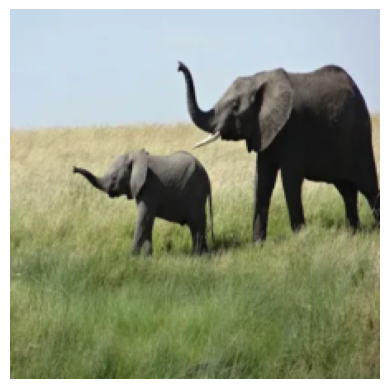

In [109]:
# Run this to test your data loader
images, labels = next(iter(dataloader))
imshow(images[0], normalize=True)

In [110]:
# We need to take a look at the VGG19 model's features, its architecture.
# VGG19 is deep CNN architecture widely used for image recognition and classification.
vgg19_model = models.vgg19(weights="DEFAULT")

vgg19_model.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [111]:
class VGG(nn.Module):
    def __init__(self):
        super(VGG, self).__init__()

        # get the pretrained VGG19 network
        self.vgg = models.vgg19(weights="DEFAULT")

        # disect the network to access its last convolutional layer
        self.features_conv = self.vgg.features[:36]

        # get the max pool of the features stem
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

        # get the classifier of the vgg19
        self.classifier = self.vgg.classifier

        # placeholder for the gradients
        self.gradients = None

    # hook for the gradients of the activations
    def activations_hook(self, grad):
        self.gradients = grad

    def forward(self, x):
        x = self.features_conv(x)

        # register the hook
        h = x.register_hook(self.activations_hook)

        # apply the remaining pooling
        x = self.max_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    # method for the gradient extraction
    def get_activations_gradient(self):
        return self.gradients

    # method for the activation exctraction
    def get_activations(self, x):
        return self.features_conv(x)

In [112]:
# initialize the VGG model
vgg = VGG()

# set the evaluation mode
vgg.eval()

# get the image from the dataloader
images, _ = next(iter(dataloader))

# keep the batch dimension: images[0:1] is (1, 3, 224, 224), not (3, 224, 224)
img = images[0:1]

# get the most likely prediction of the model
pred = vgg(img).argmax(dim=1)

In [115]:
# get the raw class scores, shape (1, 1000)
pred = vgg(img)

# read off the most likely class — this is where the 386 comes from
pred.argmax(dim=1)        # -> tensor([386]), African elephant

In [ ]:
pred[:, 386].backward()

In [116]:
# pull the gradients out of the model
gradients = vgg.get_activations_gradient()

In [117]:
# pool the gradients across the channels
pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

In [118]:
# get the activations of the last convolutional layer
activations = vgg.get_activations(img).detach()

In [119]:
# weight the channels by corresponding gradients
for i in range(512):
    activations[:, i, :, :] *= pooled_gradients[i]

In [120]:
# average the channels of the activations
heatmap = torch.mean(activations, dim=1).squeeze()

In [121]:
# relu on top of the heatmap
# expression (2) in https://arxiv.org/pdf/1610.02391.pdf
heatmap = np.maximum(heatmap, 0)

/tmp/ipykernel_4869/1678595836.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap, 0)


In [122]:
# normalize the heatmap
heatmap /= torch.max(heatmap)

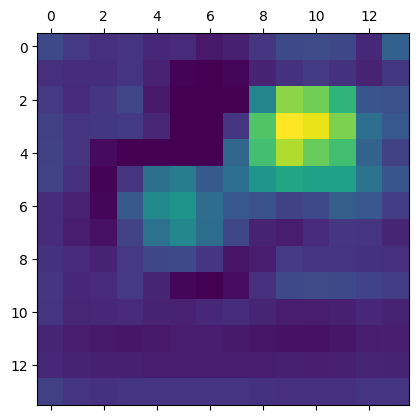

In [123]:
# draw the heatmap
plt.matshow(heatmap.squeeze())

<Axes: >

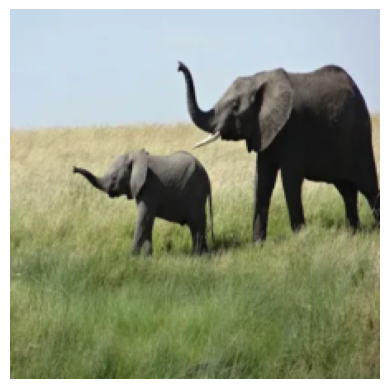

In [124]:
imshow(images[0], normalize=True)